# Analysis of the extracted articles.


In [ ]:
# Bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [ ]:
# Montar o google drive

from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Mostrar o caminho correto

import os

# Caminho até a pasta analysis
folder = "/content/drive/MyDrive/Mestrado Carol/Revisão de Escopo/data_mining/analysis"

# Listar arquivos da pasta
os.listdir(folder)


['scope_review_ data_ analysis.ipynb',
 'zotero_articles',
 'exploded_technique.gsheet',
 'scoping review - tables.xlsx']

In [ ]:
# ler os dados

df = pd.read_excel(
    "/content/drive/MyDrive/Mestrado Carol/Revisão de Escopo/data_mining/analysis/scoping review - tables.xlsx",
    sheet_name="Extraction",
    dtype=str
)

df.head()
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 162 entries, 0 to 161
Data columns (total 13 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   article_id                          162 non-null    object
 1   year_publication                    162 non-null    object
 2   database                            162 non-null    object
 3   disproportionality_techniques       162 non-null    object
 4   data_mining_algorithms_techiniques  162 non-null    object
 5   other_techniques                    162 non-null    object
 6   drug_class                          162 non-null    object
 7   start_data_collection               161 non-null    object
 8   end_data_collection                 162 non-null    object
 9   open_data                           162 non-null    object
 10  country                             162 non-null    object
 11  dataset_ made_ available            162 non-null    object

# Standardization of the ATC variable



Extracting ATC codes

From drug_class, extract all possible ATC codes.

In [ ]:
def extract_atc_codes(text):
    if pd.isna(text):
        return []
    return re.findall(r"[A-Z]\d{2}[A-Z0-9]{0,4}", text)

df["atc_list"] = df["drug_class"].apply(extract_atc_codes)
df["atc_class"] = df["atc_list"].apply(
    lambda lst: list(set(code[:3] for code in lst))
)


In [ ]:
df[["drug_class", "atc_list", "atc_class"]].head(150)


,drug_class,atc_list,atc_class
0,"J01AA08 (Minocycline), J01BA01(Chloramphenicol...","[J01AA08, J01BA01, J01MA14]",[J01]
1,"A10BA02 (Metformin), A10BK (SGLT-2 Inhibitors)","[A10BA02, A10BK]",[A10]
2,"N05BA01 (Diazepam), N05BA04 (Oxazepam), N05BA0...","[N05BA01, N05BA04, N05BA06, N05BA08, N05BA12, ...",[N05]
3,D11AH05 (Dupilumab),[D11AH05],[D11]
4,"N05 (Psycholeptics), N06 (Psychoanaleptics)","[N05, N06]","[N05, N06]"
...,...,...,...
145,N07XX13 (Valbenazine,[N07XX13],[N07]
146,"""J05AR18 (emtricitabine, tenofovir alafenamide...",[J05AR18],[J05]
147,J01FA10 (Azithromycin),[J01FA10],[J01]
148,A10BK (SGLT-2 Inhibitors),[A10BK],[A10]


# ANALYSIS OF THERAPEUTIC CLASS AND MEDICATIONS

## 1 — Quantas classes por artigo

In [ ]:
df["n_classes"] = df["atc_class"].apply(len)

dist_classes = (
    df["n_classes"]
    .value_counts()
    .sort_index()
    .reset_index()
)

dist_classes.columns = ["n_classes", "N"]

dist_classes["%"] = round(
    100 * dist_classes["N"] / dist_classes["N"].sum(), 1
)

dist_classes


,n_classes,N,%
0,0,3,1.9
1,1,138,85.2
2,2,10,6.2
3,3,3,1.9
4,4,1,0.6
5,5,2,1.2
6,6,2,1.2
7,8,1,0.6
8,9,2,1.2


## 2 — Classes terapêuticas mais estudadas

In [ ]:
class_counts = (
    df.explode("atc_class")
      .groupby("atc_class")
      .article_id
      .nunique()
      .reset_index(name="N")
      .sort_values("N", ascending=False)
)

total_articles = df.article_id.nunique()

class_counts["%"] = round(
    100 * class_counts["N"] / total_articles, 1
)

class_counts.head(10)


,atc_class,N,%
26,L01,43,26.5
28,L04,17,10.5
36,N05,17,10.5
23,J01,13,8.0
4,A10,13,8.0
37,N06,11,6.8
25,J05,10,6.2
35,N03,8,4.9
34,N02,7,4.3
0,A02,5,3.1


## 3 — Medicamentos mais estudados

In [ ]:
drug_counts = (
    df.explode("atc_list")
      .groupby("atc_list")
      .article_id
      .nunique()
      .reset_index(name="N")
      .sort_values("N", ascending=False)
)

drug_counts["%"] = round(
    100 * drug_counts["N"] / total_articles, 1
)

drug_counts.head(10)


,atc_list,N,%
138,L01FF05,8,4.9
134,L01FF01,8,4.9
135,L01FF02,8,4.9
136,L01FF03,8,4.9
137,L01FF04,7,4.3
144,L01FX04,6,3.7
229,N05AH04,5,3.1
16,A10BK,5,3.1
145,L01FX05,4,2.5
233,N05AX13,4,2.5


# GEOGRAPHICAL ANALYSIS

In [ ]:
df["country_clean"] = (
    df["country"]
    .str.strip()
    .str.title()
)


In [ ]:
country_dict = {
    "South Korea": "South Korea",
    "Korea": "South Korea",
    "Türkiye": "Turkey",
    "United States Of America": "United States",
}


In [ ]:
df["country_std"] = df["country_clean"].replace(country_dict)


In [ ]:
country_counts = (
    df["country_std"]
    .value_counts()
    .reset_index()
)

country_counts.columns = ["country", "n"]
country_counts["percent"] = country_counts["n"] / country_counts["n"].sum() * 100

country_counts


,country,n,percent
0,China,120,74.074074
1,India,8,4.938272
2,Japan,7,4.320988
3,South Korea,7,4.320988
4,United States,7,4.320988
5,Greece,2,1.234568
6,Saudi Arabia,1,0.617284
7,Turkey,1,0.617284
8,Pakistan,1,0.617284
9,Germany,1,0.617284


In [ ]:
country_counts.head(10)


,country,n,percent
0,China,120,74.074074
1,India,8,4.938272
2,Japan,7,4.320988
3,South Korea,7,4.320988
4,United States,7,4.320988
5,Greece,2,1.234568
6,Saudi Arabia,1,0.617284
7,Turkey,1,0.617284
8,Pakistan,1,0.617284
9,Germany,1,0.617284


# ANÁLISE POR BASE DE DADOS USADO

In [ ]:
counts_raw = df["database"].value_counts().reset_index()
counts_raw.columns = ["database", "n"]
counts_raw["percent"] = counts_raw["n"] / counts_raw["n"].sum() * 100

counts_raw


,database,n,percent
0,FAERS,135,83.333333
1,KIDS-KD/KAERS,7,4.320988
2,OpenVigil,5,3.086420
3,VigiBase,3,1.851852
4,"FAERS, JADER",3,1.851852
5,JADER,3,1.851852
6,VigiLyze,1,0.617284
7,"JADER, FAERS",1,0.617284
8,"FAERS, VigiAccess",1,0.617284
9,Netherlands Pharmacovigilance Centre Lareb Dat...,1,0.617284


In [ ]:
df["database_norm"] = (
    df["database"]
    .str.split(",")
    .apply(lambda x: ", ".join(sorted([i.strip() for i in x])))
)


In [ ]:
counts_norm = df["database_norm"].value_counts().reset_index()
counts_norm.columns = ["database", "n"]
counts_norm["percent"] = counts_norm["n"] / counts_norm["n"].sum() * 100

counts_norm


,database,n,percent
0,FAERS,135,83.333333
1,KIDS-KD/KAERS,7,4.320988
2,OpenVigil,5,3.086420
3,"FAERS, JADER",4,2.469136
4,VigiBase,3,1.851852
5,JADER,3,1.851852
6,VigiLyze,1,0.617284
7,"FAERS, VigiAccess",1,0.617284
8,Netherlands Pharmacovigilance Centre Lareb Dat...,1,0.617284
9,"FAERS, VigiBase",1,0.617284


In [ ]:
df_exploded = (
    df
    .assign(database=df["database_norm"].str.split(","))
    .explode("database")
)

df_exploded["database"] = df_exploded["database"].str.strip()


In [ ]:
counts_single = df_exploded["database"].value_counts().reset_index()
counts_single.columns = ["database", "n"]
counts_single["percent"] = counts_single["n"] / counts_single["n"].sum() * 100

counts_single


,database,n,percent
0,FAERS,142,84.023669
1,KIDS-KD/KAERS,7,4.142012
2,JADER,7,4.142012
3,OpenVigil,5,2.958580
4,VigiBase,4,2.366864
5,VigiAccess,1,0.591716
6,VigiLyze,1,0.591716
7,Netherlands Pharmacovigilance Centre Lareb Dat...,1,0.591716
8,Taiwan’s National Health Insurance Research Da...,1,0.591716


In [ ]:
from itertools import combinations
from collections import Counter

pairs = Counter()

for x in df["database_norm"].dropna():
    bases = x.split(", ")
    if len(bases) > 1:
        for pair in combinations(bases, 2):
            pairs[pair] += 1

pairs_df = pd.DataFrame(pairs.items(), columns=["pair", "n"])
pairs_df["pair"] = pairs_df["pair"].apply(lambda x: " + ".join(x))
pairs_df["percent"] = pairs_df["n"] / pairs_df["n"].sum() * 100
pairs_df.sort_values("n", ascending=False)


,pair,n,percent
1,FAERS + JADER,4,57.142857
0,FAERS + VigiAccess,1,14.285714
2,FAERS + VigiBase,1,14.285714
3,FAERS + Taiwan’s National Health Insurance Res...,1,14.285714


# ANALYSIS BY YEAR OF PUBLICATION

In [ ]:
# garantir que o ano está como inteiro
df['year_publication'] = df['year_publication'].astype(int)

# total de artigos
total_articles = df['article_id'].nunique()

# contagem por ano
year_stats = (
    df
    .groupby('year_publication')['article_id']
    .nunique()
    .reset_index(name='N')
)

# porcentagem
year_stats['%'] = (
    year_stats['N'] / total_articles * 100
).round(1)

# ordenar por ano (temporal)
year_stats = year_stats.sort_values(by='year_publication')

year_stats


,year_publication,N,%
0,2015,1,0.6
1,2016,1,0.6
2,2017,3,1.9
3,2018,10,6.2
4,2019,4,2.5
5,2020,8,4.9
6,2021,12,7.4
7,2022,15,9.3
8,2023,21,13.0
9,2024,53,32.7


In [ ]:
year_stats['cumulative_N'] = year_stats['N'].cumsum()
year_stats


,year_publication,N,%,cumulative_N
0,2015,1,0.6,1
1,2016,1,0.6,2
2,2017,3,1.9,5
3,2018,10,6.2,15
4,2019,4,2.5,19
5,2020,8,4.9,27
6,2021,12,7.4,39
7,2022,15,9.3,54
8,2023,21,13.0,75
9,2024,53,32.7,128


In [ ]:
def year_period(year):
    if year <= 2017:
        return '≤2017'
    elif 2018 <= year <= 2020:
        return '2018–2020'
    elif 2021 <= year <= 2023:
        return '2021–2023'
    else:
        return '2024–2025'

df['period'] = df['year_publication'].apply(year_period)

period_stats = (
    df
    .groupby('period')['article_id']
    .nunique()
    .reset_index(name='N')
)

period_stats['%'] = (
    period_stats['N'] / total_articles * 100
).round(1)

period_stats


,period,N,%
0,2018–2020,22,13.6
1,2021–2023,48,29.6
2,2024–2025,87,53.7
3,≤2017,5,3.1


In [ ]:
# Definir df_db a partir do df_exploded criado anteriormente
df_db = df_exploded.copy()
# Criar a coluna database_std usada nas análises
df_db['database_std'] = df_db['database']

# garantir tipo correto
df_db['year_publication'] = df_db['year_publication'].astype(int)

# tabela cruzada ano x base
year_database = (
    df_db
    .groupby(['year_publication', 'database_std'])['article_id']
    .nunique()
    .reset_index(name='N')
    .sort_values(['year_publication', 'N'], ascending=[True, False])
)

year_database

,year_publication,database_std,N
0,2015,FAERS,1
1,2016,FAERS,1
2,2017,FAERS,2
3,2017,KIDS-KD/KAERS,1
4,2018,FAERS,8
5,2018,JADER,2
6,2018,Netherlands Pharmacovigilance Centre Lareb Dat...,1
7,2018,Taiwan’s National Health Insurance Research Da...,1
8,2019,FAERS,3
9,2019,JADER,1


In [ ]:
year_database_wide = (
    df_db
    .pivot_table(
        index='year_publication',
        columns='database_std',
        values='article_id',
        aggfunc='nunique',
        fill_value=0
    )
    .sort_index()
)

year_database_wide


database_std,FAERS,JADER,KIDS-KD/KAERS,Netherlands Pharmacovigilance Centre Lareb Database,OpenVigil,Taiwan’s National Health Insurance Research Database (NHIRD),VigiAccess,VigiBase,VigiLyze
year_publication,,,,,,,,,
2015,1,0,0,0,0,0,0,0,0
2016,1,0,0,0,0,0,0,0,0
2017,2,0,1,0,0,0,0,0,0
2018,8,2,0,1,0,1,0,0,0
2019,3,1,0,0,0,0,0,0,1
2020,5,1,2,0,0,0,0,0,0
2021,10,0,1,0,0,0,0,1,0
2022,14,0,0,0,0,0,0,1,0
2023,19,0,1,0,1,0,0,0,0


In [ ]:
# criar categoria FAERS vs Outras
df_db['database_group'] = df_db['database_std'].apply(
    lambda x: 'FAERS' if x == 'FAERS' else 'Other databases'
)

year_faers = (
    df_db
    .groupby(['year_publication', 'database_group'])['article_id']
    .nunique()
    .reset_index(name='N')
    .sort_values('year_publication')
)

year_faers


,year_publication,database_group,N
0,2015,FAERS,1
1,2016,FAERS,1
2,2017,FAERS,2
3,2017,Other databases,1
4,2018,FAERS,8
5,2018,Other databases,4
6,2019,FAERS,3
7,2019,Other databases,2
8,2020,FAERS,5
9,2020,Other databases,3


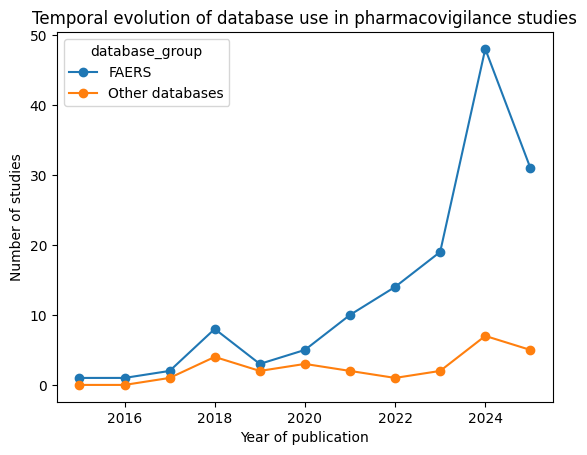

In [ ]:
import matplotlib.pyplot as plt

# usar o df_db já padronizado
df_db['database_group'] = df_db['database_std'].apply(
    lambda x: 'FAERS' if x == 'FAERS' else 'Other databases'
)

year_faers = (
    df_db
    .groupby(['year_publication', 'database_group'])['article_id']
    .nunique()
    .reset_index(name='N')
)

# pivot para plot
plot_data = year_faers.pivot(
    index='year_publication',
    columns='database_group',
    values='N'
).fillna(0)

# plot
plot_data.plot(marker='o')
plt.xlabel('Year of publication')
plt.ylabel('Number of studies')
plt.title('Temporal evolution of database use in pharmacovigilance studies')
plt.show()


# DATA COLLECTION ANALYSIS

In [ ]:
# garantir formato numérico
df['start_data_collection'] = pd.to_numeric(df['start_data_collection'], errors='coerce')
df['end_data_collection'] = pd.to_numeric(df['end_data_collection'], errors='coerce')

# calcular duração (anos)
df['data_collection_duration'] = (
    df['end_data_collection'] - df['start_data_collection'] + 1
)

# estatísticas descritivas
df['data_collection_duration'].describe()


,data_collection_duration
count,154.000000
mean,13.370130
std,8.436577
min,1.000000
25%,7.000000
50%,12.000000
75%,18.000000
max,52.000000


<Axes: >

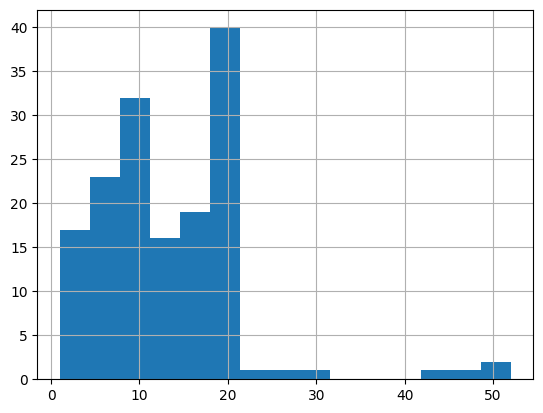

In [ ]:
df['data_collection_duration'].hist(bins=15)


# ANALYSIS BY DATA AVAILABILITY

In [ ]:
# padronizar open_data
df['open_data'] = (
    df['open_data']
    .astype(str)
    .str.strip()
    .str.lower()
)

df['open_data_std'] = df['open_data'].replace({
    'yes': 'Yes',
    'no': 'No'
})


In [ ]:
open_data_stats = (
    df
    .groupby('open_data_std')['article_id']
    .nunique()
    .reset_index(name='N')
)

open_data_stats['%'] = (
    open_data_stats['N'] / df['article_id'].nunique() * 100
).round(1)

open_data_stats


,open_data_std,N,%
0,No,13,8.0
1,Yes,149,92.0


In [ ]:
df.columns


Index(['article_id', 'year_publication', 'database',
       'disproportionality_techniques', 'data_mining_algorithms_techiniques',
       'other_techniques', 'drug_class', 'start_data_collection',
       'end_data_collection', 'open_data', 'country',
       'dataset_ made_ available', 'reference_vancouver', 'atc_list',
       'atc_class', 'n_classes', 'country_clean', 'country_std',
       'database_norm', 'period', 'data_collection_duration', 'open_data_std'],
      dtype='object')

In [ ]:
df = df.rename(columns={
    'dataset_ made_ available': 'dataset_made_available'
})


In [ ]:
df['dataset_made_available'] = (
    df['dataset_made_available']
    .astype(str)
    .str.strip()
    .str.lower()
)

df['dataset_available_std'] = df['dataset_made_available'].replace({
    'yes': 'Yes',
    'no': 'No'
})


In [ ]:
dataset_available_stats = (
    df
    .groupby('dataset_available_std')['article_id']
    .nunique()
    .reset_index(name='N')
)

dataset_available_stats['%'] = (
    dataset_available_stats['N'] / df['article_id'].nunique() * 100
).round(1)

dataset_available_stats


,dataset_available_std,N,%
0,No,160,98.8
1,Yes,2,1.2


# ANALYSIS BY TECHNIQUES

In [ ]:
DICTIONARY = {

    "disproportionality": [
        "reporting odds ratio", "ror",
        "sror", "compressed reporting odds ratio",
        "proportional reporting ratio", "prr",
        "information component", "ic",
        "bayesian confidence propagation neural network", "bcpnn",
        "multi-item gamma poisson shrinker", "mgps",
        "empirical bayes geometric mean", "ebgm",
        "gamma poisson shrinker", "gps",
        "mhra method",
        "case/non-case analysis",
        "case-only odds ratio",
        "relative reporting ratio",
        "shrinkage measure model",
        "multiplicative interaction model", "mi",
        "additive interaction model", "ai",
        "combination risk ratio", "cr",
        "combination risk ratio model", "crr",
        "statistical shrinkage transformation",
        "crude odds ratio"
    ],

    "descriptive_statistics": [
        "descriptive statistics",
        "time-to-onset", "time-to-event",
        "serious outcomes rate",
        "geographic and demographic analysis",
        "hospitalization rate",
        "volcano plot",
        "austin bradford-hill criteria",
        "co-report analysis"
    ],

    "statistical_test": [
        "chi-square", "chi square",
        "chi-square test",
        "mann-whitney", "mann-whitney u",
        "kruskal-wallis",
        "fisher", "fisher exact",
        "weibull",
        "likelihood ratio test",
        "hosmer-lemeshow",
        "kaplan-meier",
        "log-rank",
        "wilcoxon rank sum",
        "wald test",
        "spearman correlation",
        "sequence ratio",
        "auc", "area under the roc curve",
        "recall",
        "precision",
        "confidence",
        "effect size",
        "false discovery rate", "fdr",
        "bonferroni",
        "anova",
        "funnel plot"
    ],

    "data_mining": [
        "association rule", "apriori",
        "network analysis",
        "hierarchical clustering",
        "tree-based scan statistic", "treescans",
        "jaccard distance",
        "lift",
        "multilabel classification"
    ],

    "machine_learning": [
        "machine learning",
        "logistic regression",
        "decision tree",
        "random forest",
        "genetic algorithm",
        "prediction model",
        "isolation forest",
        "extended isolation forest",
        "k-means",
        "hierarchical k-means",
        "spectral clustering",
        "gaussian mixture model", "gmm",
        "target adverse-event profile",
        "f-measure maximization"
    ],

    "other": [
        "naranjo",
        "support",
        "summary of product characteristics",
        "rxnorm",
        "protein-protein interaction",
        "ppi",
        "pathway enrichment",
        "kegg pathway",
        "molecular data integration",
        "receptor occupancy",
        "in silico",
        "molecular docking",
        "generalized variance inflation factor",
        "vif",
        "calibration curve",
        "bootstrap",
        "baker-hubert gamma",
        "cross-talk analysis",
        "concomitant medication analysis",
        "causality analysis",
        "who-umc",
        "adverse outcome pathways", "aop"
    ]
}

In [ ]:
def match_keyword(text: str, keyword: str) -> bool:
    if not text:
        return False

    pattern = r'(?<!\w)' + re.escape(keyword) + r'(?!\w)'
    return re.search(pattern, text) is not None

In [ ]:
def classify_disproportionality(text):
    if pd.isna(text):
        return False

    text = text.lower()

    for k in DICTIONARY["disproportionality"]:
        if match_keyword(text, k):
            return True

    return False

df["has_disproportionality"] = (
    df["disproportionality_techniques"]
    .apply(classify_disproportionality)
)

In [ ]:
def classify_other_methods(row):
    approaches = []

    text = (
        (row["data_mining_algorithms_techiniques"] or "") + " " +
        (row["other_techniques"] or "")
    ).lower()

    for approach in [
        "data_mining",
        "machine_learning",
        "statistical_test",
        "descriptive_statistics",
        "other"
    ]:
        for k in DICTIONARY[approach]:
            if match_keyword(text, k):
                approaches.append(approach)
                break

    if row["has_disproportionality"]:
        approaches.append("disproportionality")

    return sorted(set(approaches))

df["computational_approach"] = df.apply(
    classify_other_methods,
    axis=1
)

In [ ]:
df_exploded = df.explode("computational_approach")

approach_stats = (
    df_exploded
    .groupby("computational_approach")["article_id"]
    .nunique()
    .reset_index(name="N")
)

approach_stats["%"] = (
    approach_stats["N"] /
    df["article_id"].nunique() * 100
).round(1)

approach_stats.sort_values("N", ascending=False)

,computational_approach,N,%
2,disproportionality,160,98.8
1,descriptive_statistics,120,74.1
5,statistical_test,64,39.5
3,machine_learning,18,11.1
4,other,11,6.8
0,data_mining,7,4.3


# ANALYSIS BY NUMBER OF TECHNIQUES

In [ ]:
def split_techniques(text):
    if not isinstance(text, str):
        return []

    text = text.lower()
    parts = re.split(r';|,|/', text)
    return [p.strip() for p in parts if p.strip()]

df['dp_techniques_raw'] = df['disproportionality_techniques'].apply(split_techniques)

In [ ]:
CANONICAL_DP = {
    "ROR": [
        "reporting odds ratio",
        "ror",
        "compressed reporting odds ratio",
        "crude odds ratio"
    ],
    "PRR": [
        "proportional reporting ratio",
        "prr",
        "relative reporting ratio"
    ],
    "IC": [
        "information component",
        "ic",
        "bayesian confidence propagation neural network",
        "bcpnn"
    ],
    "EBGM": [
        "empirical bayes geometric mean",
        "ebgm",
        "multi-item gamma poisson shrinker",
        "mgps",
        "gamma poisson shrinker",
        "gps"
    ],
    "sROR": [
        "case-only odds ratio",
        "sror"
    ]
}

In [ ]:
def normalize_dp_techniques(tech_list):
    normalized = set()

    for tech in tech_list:
        for canonical, aliases in CANONICAL_DP.items():
            for alias in aliases:
                pattern = r'\b' + re.escape(alias) + r'\b'
                if re.search(pattern, tech):
                    normalized.add(canonical)
                    break

    return sorted(normalized)

df['dp_techniques_norm'] = df['dp_techniques_raw'].apply(normalize_dp_techniques)
df['n_dp_techniques'] = df['dp_techniques_norm'].apply(len)
df['n_dp_techniques'].value_counts().sort_index()

,count
n_dp_techniques,
0,3
1,37
2,38
3,27
4,57


In [ ]:
df['methods_text'] = (
    df['disproportionality_techniques'].fillna('') + ' ' +
    df['data_mining_algorithms_techiniques'].fillna('') + ' ' +
    df['other_techniques'].fillna('')
).str.lower()

df.loc[df['n_dp_techniques'] == 0, [
    'article_id',
    'disproportionality_techniques',
    'methods_text'
]]

,article_id,disproportionality_techniques,methods_text
36,37,"Combination Risk Ratio Model (CRR), Shrinkage ...","combination risk ratio model (crr), shrinkage ..."
70,71,Not used,not used logistic regression additive interact...
161,162,Not used,"not used k-means, hierarchical k-means (hk-mea..."


In [ ]:
single_dp_articles = df[df['n_dp_techniques'] == 1]

single_dp_distribution = (
    single_dp_articles
    .explode('dp_techniques_norm')
    .groupby('dp_techniques_norm')['article_id']
    .nunique()
    .reset_index(name='N')
    .sort_values('N', ascending=False)
)

single_dp_distribution

,dp_techniques_norm,N
2,ROR,27
1,PRR,5
3,sROR,3
0,IC,2
